# **Damage propagation in a U-bolt:**
In the following parts we will focus on the problem of damage propagation over time. In the following lines of code we will upload the data computed by solving a **F.O.M.**.
This high fidelity solutions are computed starting from the **Fisher-KPP** equation:
<br><br><br>
$$
\begin{cases}
\frac{\partial u}{\partial t} - D \Delta u = r u(1-u) & \text{in } \Omega \times (0,T], \\
\nabla u \cdot \mathbf{n} = 0 & \text{on } \partial \Omega \times (0,T], \\
u(\cdot, 0) = g_\delta & \text{in } \Omega,
\end{cases}
$$
<br><br><br>
where $D > 0$ and $r > 0$ are the **diffusion and reaction coefficients**, respectively, whereas $\delta > 0$ is a parameter describing the location of **the initial damage**. While, the solution $u : \Omega \times [0, T] \rightarrow [0, 1]$ indicates the level of damage:

*   $u$ equal to $1$ indicates maximum damage
*   $u$ equal to $0$ indicates no damage



 Then for $g_\delta$ we have that:


$$
g_\delta(x,y) :=
\begin{cases}
1 & \text{if } |x - \delta| < 0.1 \text{ and } y \geq 4, \\
0 & \text{otherwise}.
\end{cases}
$$


For the sake of our analysis, we parametrize the model coefficients as


$$
D = 10^{\mu_1}, \quad r = 10^{\mu_2 + 2}, \quad \delta = \mu_3 + 1,
$$


where $\mu = [\mu_1, \mu_2, \mu_3]^\top$ varies in $[0,1]^3$. The final time is set to $T = 0.02$.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
import time
from IPython.display import clear_output as clc
import torch
from torch import tanh
from torch.optim import Adam

In [ ]:
# Fancy colormap for plotting
from matplotlib.colors import ListedColormap
import matplotlib as mpl
jet = mpl.colormaps['jet']
jet_colors = jet(np.linspace(0, 1, 256))
def modify_jet_to_gray(jet_colors):
    new_colors = jet_colors.copy()
    gray_vals = np.linspace(0.3, 0.7, 85)
    for i in range(85):
        new_colors[i, 0:3] = gray_vals[i]
    return ListedColormap(new_colors)
gray_jet = modify_jet_to_gray(jet_colors)

In [ ]:
# FOM discretization
import gdown
gdown.download(id = "1_4uC_yjWmvaDfAuRt0I1PI3IENE4XYXX", output = "ubolt_mesh.xml")
mesh = fe.loadmesh("ubolt_mesh.xml")
Vh = fe.space(mesh, 'CG', 1)

Downloading...
From (original): https://drive.google.com/uc?id=1_4uC_yjWmvaDfAuRt0I1PI3IENE4XYXX
From (redirected): https://drive.google.com/uc?id=1_4uC_yjWmvaDfAuRt0I1PI3IENE4XYXX&confirm=t&uuid=c1e2998f-195e-46a9-aca4-f3c0e940d490
To: /content/ubolt_mesh.xml
100%|██████████| 1.33M/1.33M [00:00<00:00, 12.8MB/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.



Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_3801828c0f66b7190a7fd5819465b3d5b34b9149

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00307488 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.817791 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representation
INFO:FFC:---------------------------

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#now we load from the drive the dataset that we have already computed
#load_path = "/content/drive/MyDrive/Colab Notebooks/MODEL ORDER REDUCTION TECHNIQUES/ASSIGNEMENT_2/" #michele
load_path = "/content/drive/MyDrive/Colab Notebooks/ASSIGNEMENT_2/ASSIGNEMENT_2/" #mamma
mu = np.load(load_path + "mu.npy")
ufom = np.load(load_path + "ufom.npy")
clc()
print(f"The shape of the parameters, mu, is: {mu.shape}")
print(f"The shape of the uFom solution is: {ufom.shape}")
print(f"In particular:")
print(f"The number of simulation, Ns, is: {ufom.shape[0]}")
print(f"The number of time step per each simulation, Nt, is: {ufom.shape[1]}")
print(f"The number of mesh nodes, Nh, is: {ufom.shape[2]}")

The shape of the parameters, mu, is: (100, 3)
The shape of the uFom solution is: (100, 41, 6636)
In particular:
The number of simulation, Ns, is: 100
The number of time step per each simulation, Nt, is: 41
The number of mesh nodes, Nh, is: 6636


In [ ]:
#we immediately pass to tensors
mu, ufom = dv.tensor(mu, ufom)

In [ ]:
#we try to see how is the singular value decay even if we know that we will not use POD-GALERKIN
ntraining = 75
ntest = 25
Ns = ufom.shape[0] #the number of simulations
Nt = ufom.shape[1] #the number of time istances
Nh = ufom.shape[2] #the number of nodes
p = mu.shape[1] #the number of parameters
delta_t = 0.0005

In [ ]:
l2 = L2(Vh) #we create the norm  and it expects input like ... x Nh
l2.cuda()
clc()

In [ ]:
#now we define the error function that we will use several times in the code

def error_func(utrue, upred):
  #we must have data written as ... x Nh, otherwise L2 doesn't work
  current_Ns = utrue.shape[0]//Nt #because this will enter also in the training and there Ns is 75
  error =  (l2(utrue-upred).reshape(current_Ns, Nt)/l2(utrue).reshape(current_Ns, Nt)).mean(axis = -1)
  error = error.mean()
  return error

In [ ]:
#WE CANNOT USE POD + GALERKIN BECAUSE THE PROBLEM IS NON LINEAR AND NON AFFINE AND SO IF WE STILL WANT TO BUILD A ROM WE MUST USE HYPER REDUCTION TECHNIQUES THAT ARE VERY EXPENSIVE

# **Construction of the POD-NN:**
The **Fisher-KPP** equation is characterized by nonlinear terms and the parameters enter in the equation in a non affine way. So, instead of using **hyper-reduction techniques**, we exploit **neural networks**. In this case the strategy that is adopted is the **POD-NN**. This is composed by:




*   **POD** to find $V\in\mathbb{R}^{N_h\times N}$
*   $\phi:\mathbb{R}^{p}\to\mathbb{R}^{n}$


Basically the $V$ and $V^T$ play the role of *compressing* and *decompressing* the information. In fact we pass from $N_h$ to $N$, then again from $N$ to $N_h$.
While $\phi$ is used to pass from the parameter domain, $p (+1)$, to the reduced space $N$.

The problem in our case is much more complex because we have to deal also with time. In fact:

*   $u_{\text{fom}}\in\mathbb{R}^{N_s\times N_t\times N_h}$;

*   $\mu\in\mathbb{R}^{N_s\times p}$;

With this approach time is considered as a further parameter, in fact $\mu$ is rewritten in this way:

$$\mu^t\in\mathbb{R}^{N_s\times N_t\times (p+1)}$$ such that
$$\mu^t_{i,j} = [\mu_{i,1},\;\mu_{i,2},\;\mu_{i,3},\;t_j]$$


where we are looking at $i$-th simulated trajectory and the $j$-th time instant.
<br><br><br>
After the training of $\phi$ we can finally create our **R.O.M.** by saying that:

$$u_{\text{fom}}\approx{V}\phi(\boldsymbol{\mu})$$


In [ ]:
#we perform the svd

#so we know that to use svd we have to put everything into a 2D numpy array and with dimension Nh x Ns*Nt
U_PODNN = ufom.detach().cpu().numpy()
U_PODNN = U_PODNN[:ntraining, :, :]
U_PODNN = np.reshape(U_PODNN, (-1, Nh))
U_PODNN = U_PODNN.T


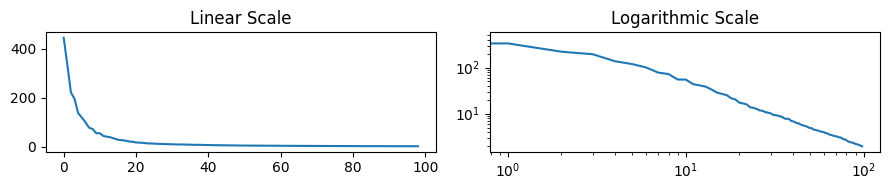

In [ ]:
#we perform the svd
X_PODNN, s_PODNN, Yt_PODNN = svd(U_PODNN, full_matrices = False)

#now we create our basis by looking at the singular values
plt.figure(figsize = (9, 2))
plt.subplot(1,2,1)
plt.plot(s_PODNN[1:100])
plt.title('Linear Scale')
plt.subplot(1,2,2)
plt.loglog(s_PODNN[1:100])
plt.title('Logarithmic Scale')
plt.tight_layout()
plt.show()

In [ ]:
print(s_PODNN.shape)
N_PODNN = 100 #2*(p + 1) + 1 #WE HAVE TO USE A BIGGER N TO OBTAIN A GOOD RESULT IN TERMS OF ACCURACY, BUT OF COURSE THIS WILL SLOW DOWN THE COMPUTATIONS
energy = np.sum(s_PODNN[:N_PODNN])/np.sum(s_PODNN)
print(f"If we choose N = {N_PODNN} we are keeping this energy: {energy*100}%")
#we can see that with a good number of number of basis function we can have a good usage of the energy, however we are not able to

(3075,)
If we choose N = 100 we are keeping this energy: 97.47306060791016%


In [ ]:
ufom_PODNN = ufom.reshape(-1, Nh)
ntrain_PODNN = ntraining*Nt
nvalidation_PODNN = int(0.2 * ntrain_PODNN)

In [ ]:
# POD-NN
#now we compute the projection error to see how is our choice of the vector V
V_PODNN = X_PODNN[:, :N_PODNN]
V_PODNN = dv.tensor(V_PODNN)

print(V_PODNN.shape)
print(ufom_PODNN[ntrain_PODNN:].shape)
#TO HAVE A GOOD PROJECTION ERRROR WE MUST USE N>=120

torch.Size([6636, 100])
torch.Size([1025, 6636])
POD MRE: 1.03%


In [ ]:
#now we do the NN for the lower space

#we start preparing our data in the form Ndata x dim_data
t_final = 0.02
mut_PODNN = torch.zeros([Ns, Nt, p +1])
times = torch.tensor(np.linspace(0, t_final, Nt))
for i in range(Ns):
    # Assign the first two parameters of mu[i] to all time steps' first two dimensions
    mut_PODNN[i,:,:p] = mu[i, :p]
    # Assign the time array to the third dimension (index 2) for all time steps
    mut_PODNN[i,:, p] = times

print(mut_PODNN.shape)

mut_PODNN = mut_PODNN.reshape(-1, p + 1) #Ndata x dim_data
mut_PODNN = dv.tensor(mut_PODNN)
print(mut_PODNN.shape)


torch.Size([100, 41, 4])
torch.Size([4100, 4])


In [ ]:
#NN
c_PODNN = ufom_PODNN @ V_PODNN #this has dimension Ns*Nt x N_PODNN

phi_PODNN = DFNN(Dense(p+1, 128, gelu) + Dense(128, 128, gelu) + Dense(128, 128, gelu) + Dense(128, N_PODNN, activation = None))
phi_PODNN.cuda()
phi_PODNN.He()

#for the phi of POD-NN and the phi for DL-ROM we used the same newtork and the same training to have a direct comparison
phi_PODNN.train(mut_PODNN, c_PODNN, ntrain = ntrain_PODNN - nvalidation_PODNN, epochs = 500, loss = mse(euclidean))



		Train		Test
Epoch 500:	4.34e-01	5.26e+00.

>> ETA: 0.28s.

Training complete. Elapsed time: 2 minutes 17.61 seconds.


In [ ]:
phi_PODNN.freeze()

In [ ]:
#we save our autoencoder to use it in other notebooks
#save_path = "/content/drive/MyDrive/Colab Notebooks/MODEL ORDER REDUCTION TECHNIQUES/ASSIGNEMENT_2/" #michele
save_path = "/content/drive/MyDrive/Colab Notebooks/ASSIGNEMENT_2/ASSIGNEMENT_2/" #mamma

In [ ]:
torch.save(phi_PODNN.state_dict(), save_path + "phi_PODNN.pt")
torch.save(V_PODNN, save_path + "V_PODNN.pt")
np.save(save_path + "N_PODNN.npy", N_PODNN)